In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit


## Scattering simulation
### Isotropically distributed unit vector
Generate a 3D unit vector with random direction (uniform distribution on the surface of the unit sphere). You can use the rejection method or the following identities
$$\cos(\theta) \sim U(-1,1)$$
$$\phi\sim U(0, 2\pi)$$


In [2]:
# using the variable transformation
@njit
def random_direction(nsampl, l=1):
    """generate nsampl 3D vectors with random directions and length l"""
    v = np.zeros((nsampl, 3))
    cos_theta = 1 - 2*np.random.uniform(0, 1, size = nsampl)
    sin_theta = np.sqrt(1-cos_theta**2)
    phi = 2*np.pi*np.random.uniform(0, 1, size = nsampl)

    v[:,0] = l*cos_theta
    v[:,1] = l*sin_theta*np.sin(phi)
    v[:,2] = l*sin_theta*np.cos(phi)
    return v


In [5]:
%timeit random_direction(1000000)
vs = random_direction(1000000)

53.2 ms ± 778 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


We can plot a 2D projection as a scatter plot or histogram to judge the distribution visually

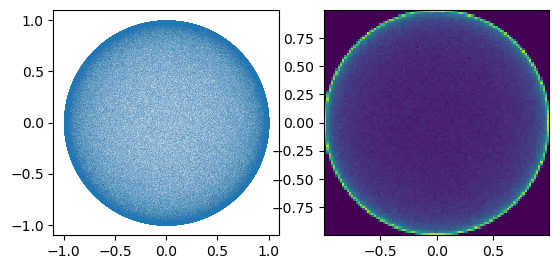

In [6]:
f, ax = plt.subplots(1,2)
ax[0].plot(vs[:,0], vs[:,1], ".", ms=1, mew=0, alpha=0.05)
ax[1].hist2d(vs[:,0], vs[:,1], bins=100)
for a in ax: a.set_aspect("equal")

In [7]:
# or using the rejection method
# the internal loop would be too slow in pure python, so use numba

from numba import njit

@njit
def random_direction_rejection(nsampl, l=1):
    """generate nsampl 3D vectors with random directions and length l"""
    v = np.zeros((nsampl, 3))
    for i in range(nsampl):
        while True:
            r = np.random.uniform(0, 1, size = 3)*2 - 1
            rnorm2 = np.dot(r,r)
            if rnorm2 <= 1:
                break
        v[i, :] = r/np.sqrt(rnorm2)
    return v

In [8]:
%%timeit
vs = random_direction_rejection(1000000)

111 ms ± 3.15 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## MC credit task option 1:

Simulate the transport of an electron swarm through neutral gas under an external electric field. The mean energy loss in a collision with a heavier particle is $2 m_e/m_g$.
Assume:
 - zero initial velocity, electrons starting from a point source
 - $m_e=1$, $q=1$, $|E| = 100$
 - $\tau=1$ mean time between collisions
 - $2m_e/m_g = 10^{-4}$ and on each collision, the electron kinetic energy is reduced by a factor $1-2m_e/m_g$.
   
calculate the position and velocity distribution after time $10\tau$. Use e.g. 10000 particles

hint: $t_{coll}\sim\frac{1}{\tau}\exp(-\frac{t}{\tau})$

inverse cdf:$-\tau\ln(x)$


In [ ]:
E = np.array([100, 0, 0])
r_coll = 1
tau_coll = 1/r_coll
m = 1
q = 1

t_max = 10
a = q*E/m
Eloss = 1e-4

@njit
def scatter(v, Eloss = 1e-4):
    """reduce energy by factor (1-Eloss) and randomly rotate v"""
    TODO
    return v

@njit
def t_col(tau):
    """return exponentially distributed t_col with mean tau"""
    
    return TODO

@njit
def propagate(v, x, a, r_coll, Eloss, t_max):
    # simulate trajectory of a single particle up to t = t_max
    # assuming constant acceleration 
    # use analytic formulas to calculate the motion between collisions
    TODO
    return v, x

